## Model Development
* to predict the price of a used car using the dataset.
* simple linear regression
* multiple linear regression
* model evaluation using visualization
* polynomial regression
* pipelines
* R-squared and MSE for sample evaluation, prediction, decision making, and how to determine a fair value.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("dark_background")

file_name = "clean_df_Auto.csv"
df = pd.read_csv(file_name, header=0, index_col=0)
df.dtypes

symboling              int64
normalized-losses      int64
make                     str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float64
stroke               float64
compression-ratio    float64
horsepower             int64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
city-L/100km         float64
highway-L/100km      float64
horsepower-binned        str
fuel-type-diesel        bool
fuel-type-gas           bool
aspiration-std          bool
aspiration-turbo        bool
dtype: object

### Linear Regression and Multiple Linear Regression

* Linear Regression will refer to one independent variable to make a prediction.
* Multiple Linear Regression will refer to multiple independent variables to make a prediction.
* Simple Linear Regression
    * a method to help us understand the relationship between two variables.
    * the predictor/independent variable, X
    * the target/dependent variable, Y
    * the result is linear function, y = a + bX, where a is ther intercept, and b is the slope.
    * when we fit or train the model, we will come up with these values.
    * with the model we can make prediction of the price of a car based on the value of x.





#### Training and Using the Model
* There are two set of data used for training the model (via the fit() method), which correpond to the X and Y values for the Linear Regression.
* Once the model trained, we can use the model to make prediction (via the predict() method).
* Note that since the model is a regression line, which is an estimation from all the data points given during the fitting, the predicted result will not be 100% correct.
* Noise prevents the predicted result to match the expected result 100% correctly.

#### To fit or train the model:
1. import the sklearn.linear_model module for the Linear Regression Model.
2. Define the predictor variable and target variable, e.g. <br>
    X = df[["highway-mpg"]]  - this predictor variable must be a DataFrame which is the dataset for X values <br>
    Y = df["price"]  - this target variable can be a Series or DataFrame which is the corresponding Y values for each X values.
3. use lm.fit(X,Y) to fit the model, which will determine the intercept (lm.intercept_) and the slope (lm.coef_).
4. Then we can use the model for prediction: <br>
    Yhat = lm.predict(X)  - note that we are using the same X dataset as we used for training above.

#### Important Note
* Eventhough we used the same training X dataset for making the prediction, the result Yhat, will likely be different from the Y dataset values we used in training. This is because the model is based on a regression line which is an estimation line from the scattered data points. These differences is a result of noise or something else which we will study later.

In [2]:

from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [3]:
# How could 'highway-mpg' help us predict car price?
X = df[['highway-mpg']]  # X must be a dataframe
Y = df[['price']]  # Y can be a series or dataframe, the return result will be a 1D array or multi-D array.
lm.fit(X,Y) # fit the linear model (train the model)
Yhat = lm.predict(X) # get the prediction
print("First 5 Predicted Result:\n",Yhat[0:5]) # get the first 5 prediction result - a 2D array bcos we feed in a DF as Y above.
print()
print("First 5 Expected Result: \n", Y[0:5])
print()
print(type(Yhat))

First 5 Predicted Result:
 [[16236.50464347]
 [16236.50464347]
 [17058.23802179]
 [13771.3045085 ]
 [20345.17153508]]

First 5 Expected Result: 
      price
0  13495.0
1  16500.0
2  16500.0
3  13950.0
4  17450.0

<class 'numpy.ndarray'>


In [4]:
X = df[['highway-mpg']]  # X must be a dataframe
Y = df['price']  # feeding Y a series, expecting output to be a 1D array
lm.fit(X,Y) # fit the linear model 
Yhat = lm.predict(X) # get the prediction
print("First 5 Predicted Result:\n",Yhat[0:5]) # get the first 5 prediction result - a 1D array bcos we feed in a Series as Y above.
print()
print("First 5 Expected Result: \n", Y[0:5])
print()
print(type(Yhat))

# For the Y input, we use Series/1D array if we only need a single value prediction for easier access.
# If we expect a multiple values output prediction, then use a dataframe. The result will be a multi-D array.

First 5 Predicted Result:
 [16236.50464347 16236.50464347 17058.23802179 13771.3045085
 20345.17153508]

First 5 Expected Result: 
 0    13495.0
1    16500.0
2    16500.0
3    13950.0
4    17450.0
Name: price, dtype: float64

<class 'numpy.ndarray'>


In [5]:
# what is the value of the intercept, a
a = lm.intercept_
a

np.float64(38423.3058581574)

In [6]:
# what is the value of the slope, b
b = lm.coef_
b

array([-821.73337832])

In [7]:
# from the above, our function for the price prediction is
#   Price = 38423 - 822 * highway-mpg

In [8]:
# Create a linear regression object
lm1 = LinearRegression()

# training the model with engine-size for price
X = df[['engine-size']]
Y = df['price']
lm1.fit(X,Y)

Yhat = lm1.predict(X)
print(Yhat[0:5])
print()
print(f"Price = {lm1.intercept_:.2f} + {lm1.coef_[0]:.2f} * df[engine-size]")

# NOTE: The coef_ or the b value is an array because LinearRegression could be a multivariate Regression, e.g. y = a + bx + b2x + b3x + ...

[13728.4631336  13728.4631336  17399.38347881 10224.40280408
 14729.62322775]

Price = -7963.34 + 166.86 * df[engine-size]


### Multiple Linear Regression (MLR) - predicting using more than one feature
As shown above, we can use different features in the dataset as the predictor of price. e.g. Horsepower, Curb-weight, Engine-size, Highway-mpg.
We can also use multiple features as predictor at the same time. For this we use the MLR.

* This model is used to explain the relationship between :
    * One continuous target (Y) variable.
    * Two or more predictor (X) variables.

* For example, if we have 4 predictor variables, then our model will look like
    * Yhat = b0 + b1x1 + b2x2 + b3x3 + b4x4
    * where 
        * b0 -> intercept (X=0)
        * b1 -> the coefficient or parameter of x1
        * b2 -> the coefficient or parameter of x2 and so on.

In [9]:
Z = df[['horsepower','curb-weight','engine-size','normalized-losses','highway-mpg']]
lm.fit(Z, df['price'])

Yhat = lm.predict(Z)
slopes = lm.coef_

print(Yhat[0:5])
print()
print(f"Price = {lm.intercept_:.2f} + {slopes[0]:.2f} * df['horsepower'] + {slopes[1]:.2f} * df['curb-weight] + {slopes[2]:.2f} * df['engine-size'] + {slopes[3]:.2f} * df['normalized-losses'] + {slopes[4]:.2f} * df['highway-mpg']")


[13692.72205916 13692.72205916 19031.20125961 10688.40410702
 15587.11330517]

Price = -16054.10 + 53.02 * df['horsepower'] + 4.72 * df['curb-weight] + 81.67 * df['engine-size'] + 1.75 * df['normalized-losses'] + 36.94 * df['highway-mpg']


### Create and train a Multiple Features Linear Regression model where the response variable price, and the predictor features is normalized-losses and highway-mpg



In [10]:
# Note: The number of columns used in training the model will produce different prediction function as shown below:
lm.fit(df[['horsepower','curb-weight','engine-size','normalized-losses','highway-mpg']], df['price'])  # using 5 features for training
Yhat = lm.predict(df[['horsepower','curb-weight','engine-size','normalized-losses','highway-mpg']])
slopes = lm.coef_
print(f"Price = {lm.intercept_:.2f} + {slopes[3]:.2f} * df['normalized-losses'] + {slopes[4]:.2f} * df['highway-mpg]")

lm.fit(df[['normalized-losses','highway-mpg']], df['price']) # using 2 features for training
Yhat = lm.predict(df[['normalized-losses','highway-mpg']])
slopes = lm.coef_
print(f"Price = {lm.intercept_:.2f} + {slopes[0]:.2f} * df['normalized-losses'] + {slopes[1]:.2f} * df['highway-mpg]")



Price = -16054.10 + 1.75 * df['normalized-losses'] + 36.94 * df['highway-mpg]
Price = 38201.31 + 1.50 * df['normalized-losses'] + -820.45 * df['highway-mpg]


### Thus the key to an accurate prediction function generated by the model will depends on the features used as inputs.
* More features does not necessary means more accurate prediction function. 
* The features used must be relevant to the intended prediction, in this case the price. 
* So features selection is very important.

<br>

### The Data Science Loop
1. Selection: choosing the Features (the X columns).
2. Creation: Create the Yhat prediction function and calculates the Parameters (coef_ and intercept_) - train the model
3. Prediction: Use the function to predict the Y - test the model
4. Evaluation: Compare the predicted results to the Actual Values (using R square or visualization)
5. Refinement: If the evaluation is not good, go back to step 1 and make necessary changes to the Features selection.


## Model Evaluation Using Visualization

### Regression Plot

* Why use Regression Plot?
    * It gives a good estimate of :
        * the relationship between two variables.
        * the strength of the correlation.
        * the direction of the relationship (positive or negative)
* Regression Plot shows us a combination of :
    * the scatterplot where each point represents a different y
    * the fitted linear regression line (Yhat)


Text(0.5, 1.0, 'Regression Plot: highway-mpg vs price')

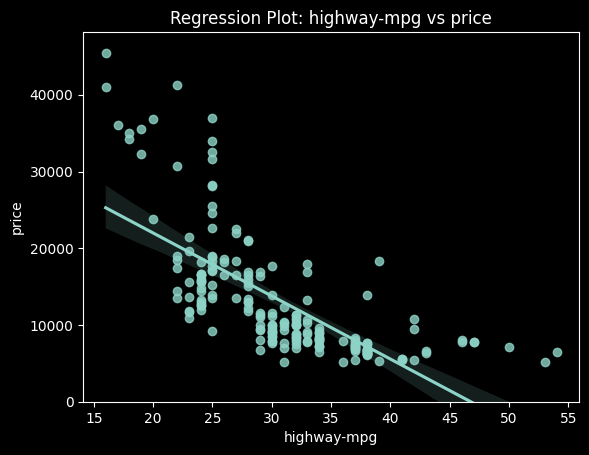

In [11]:
import seaborn as sns

# for simple single feature linear regression, the best way to visualize the fit of our model is by using regression plots
#plt.figure(figsize=(12,10))
sns.regplot(x='highway-mpg',y='price',data=df)
plt.ylim(0,)
plt.title('Regression Plot: highway-mpg vs price')

# The plot shows that price is negatively correlated to highwayj-mpg since the slope is negative.
# Looking at the scattering of the data points around the regression line, this give a good indication that
# the variance of the data and whether a linear model would be the best fit or not.
# If the data is too far off from the line, then the linear model might not be the best model for this data set.
# Looking at the data points, it seems like a curve line (model) will be a better fit.

Correlation of Price and highway-mpg is -0.704692265058953
Correlation of Price and peak-rpm is -0.10161587407588138


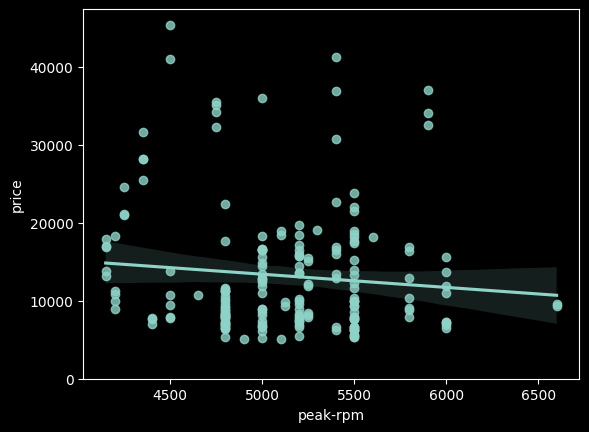

In [12]:
# We can compare the above with another plot for peak-rpm.
#plt.figure(figsize=(12,10))
sns.regplot(x='peak-rpm',y='price',data=df)
plt.ylim(0,)
# Comparing to the highway-mpg plot, we see that the points for highway-mpg are much closer to the generated line and, on average,
# decrease. The points for peak-rpm are more spread out and it is much harder to determine if the points are decreasing or increasing.
# We can verify by looking at their corr coefficients.
for param in ['highway-mpg','peak-rpm']:
    print(f"Correlation of Price and {param} is", df[param].corr(df["price"]))


# Thus we can say that the model for highway-mpg is a better fit than the model for peak-rpm.

# Why Visualizing the regression is better than comparing the correlation number:
# 1. Linearity Trap 
#     Correlation coefficient measures how well points fit a straight line. If the data is curved, the correlation might still be high,
#     but the straight line will be a terrible predictor.
#     The plot will show the points curving away from the line, signaling a better model is needed.

# 2. Identifying Outliers
#     One or two outliers might pull the correlation coefficient down significantly. 
#     The plot, however will shows where the problem is.

# 3. Understanding the Spread (variance)
#     If the points are close to the line a low mpg but fly everwhere at high mpt, the model is unstable at certain range.
#     Correlation shows how much x and y move together, but the plot shows us the prediction interval.

# Use df.corr() to quickly rank which features are worth looking at.
# Use sns.regplot() on the top 2 or 3 features to see if a linear model is actually appropriate.

# Note that even though we have not create and train the model, Seaborn is doing it in the background. The trained
# model is actually the regression line shown.

#### Residual Plot
* The Residual Plot represents the error between the predicted value and the actual value.

* residual(e) - the difference between the observed value(y) and the predicted value (Yhat).
* Looking at the regression plot, the residual is the distance from the data point to the fitted regression line.
* A residual plot is a graph that shows the residuals on the vertical y-axis vs the independent variable on the x-axis.
* If the points in a residual plot are randomly spread out around the x-axis, then a linear model is appropriate for the data.
* Randomly spread out residuals means that the variance is constant, and thus the linear model is a good fit for the data.


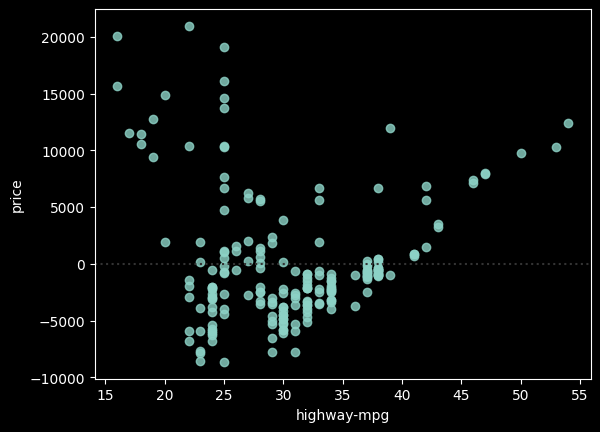

In [13]:

sns.residplot(x=df['highway-mpg'], y=df['price'])
plt.show()


#### From the above Residual Plot, we can see that:

* the residual points are not randomly spread out along the x-axis, hence maybe a non-linear model is more appropriate for this data.
* If all the points fall on the X-axis, then we have a perfect prediction model !!

* What it shows: The distance of each point from the predicted line.
* The Goal: You want the dots to be randomly spread out around the center line (0).
* The Warning: If you see a pattern (like a "U" shape or a curve), it means your linear model is missing a non-linear relationship.

* Points above the line = the model under-predicted (car is more expensive than predicted)
* Points below the line = the model is over-predicted (car is cheaper than predicted)

#### Here is a visual example of a perfectly fit model using Residual Plot

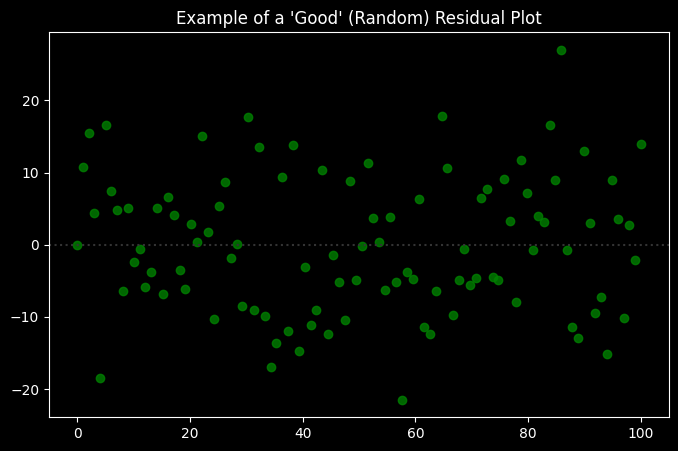

In [14]:
# Create perfectly linear data with random noise
x = np.linspace(0, 100, 100)
y = 2 * x + np.random.normal(0, 10, 100) # The "10" is the noise

plt.figure(figsize=(8, 5))
sns.residplot(x=x, y=y, color="green")
plt.title("Example of a 'Good' (Random) Residual Plot")
plt.show()

### Visualizing a Mode for Multiple Features Linear Regression


#### Distribution Plots
* these plots are extremely useful for visualizing models with more than one independent variable or feature.
* we plot the fitted values vs the actual values.
* the plot will shows the differences visually how far the predicted values deviate from the actual values.


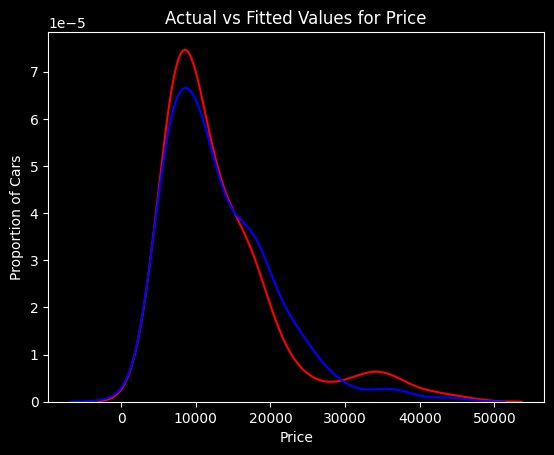

In [15]:
Z = df[['horsepower','curb-weight','engine-size','normalized-losses','highway-mpg']]
lm.fit(Z, df['price'])

# 1. make a prediction
Yhat = lm.predict(Z)

# 2. Visualize in a Density Distribution Plot
ax1 = sns.kdeplot(df['price'], color="r", label="Actual Value")
sns.kdeplot(Yhat, color="b", label="Fitted Value", ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of Cars')

plt.show()

     


### What the above Distribution Plots tells us :
* Mean and Median Alignment:
    * If the 'peaks' of the curves align, it means the model is getting the average prices correct.
* Spread (Variance):
    * If the width of the curves is the same, the model understands the range of prices.
* Accuracy:
    * The more the 'Fitted' (Predicted) curve hugs the 'Actual' curve, the more reliable the multi-feature equation is.

#### In a density plot (KDE), the total area under the curve must always equal 1. So, if one peak is shorter, the curve must be wider elsewhere to make up for it.

### What it means when the Actual peak is taller than the Fitted:
* If your Fitted peak is shorter and broader than the Actual peak, it means your model is over-estimating the variance.
* The Actual Data: Most cars are priced very consistently around a specific "average" (the tall, skinny peak).
* Your Model: Your model is "guessing" prices that are a bit more spread out. It’s predicting more variety in prices than actually exists.

### Why does this happen?
* This usually occurs for one of two reasons:
    1. Missing a "Stabilizing" Feature: There might be a feature you haven't included that keeps prices consistent (like "Brand Reputation" or "Model Year"). Without it, the model's predictions "wobble" more than the real-world prices do.
    2. Multicollinearity: If your features are fighting with each other (e.g. horsepower vs. engine-size), the math can get slightly unstable, leading to a wider spread of predicted values.

### Summary of Peak Height
|   Visual Observation	       | Mathematical Meaning	            | Model Character |
|:---|:---|:---|
|   Peaks Align (Horizontal)   | Means match (average is correct).	| The model is "on target." |
|   Actual Peak is Higher	   | Predicted spread is too wide.	    | The model is a bit "noisy" or "shaky." |
|   Fitted Peak is Higher	   | Predicted spread is too narrow.	    | The model is "too cautious" or "boring."    |

<p> </p>

## Polynomial Regression and Pipelines

So far we have deal with Simple Linear Regression and Multi Features Linear Regression. These are straight lines.
However, in many cases a curves function modeling fits better. These are Polynomial Equation.
* Polynomial Regression is a special case of the general linear regression.
* We use Polynomial Regression to model these type of behaviour.
* Polynomial regression is a particular case of the general linear regression model or multiple linear regression models.
* We get non-linear relationships by squaring or setting higher order terms of the predictor variables.
* Second order polynomial regression are for Quadratic equations.
* Third order are for the Cubic, and there could also be Higher Order above the third.
* In all cases, the relationship between the variable and the parameter is always linear.
* We can use the numpy.polyfit() to generate the model. However this only works for model with single feature.
* Pipelines are a way to simplify our code.

Earlier in the linear model it did not provide the best fit while using 'highway-mpg' as the predictor variable (feature).
Let's see if we can get a better fit using a polynomial model.

        3         2
-1.557 x + 204.8 x - 8965 x + 1.379e+05


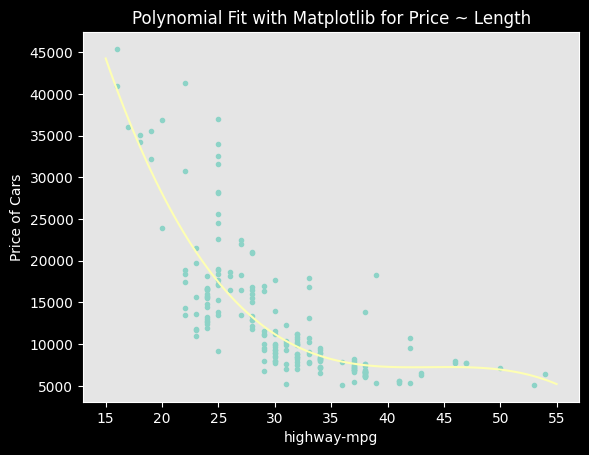

array([-1.55663829e+00,  2.04754306e+02, -8.96543312e+03,  1.37923594e+05])

In [16]:
# A graph plotting function that accept a model, result variables (Y), input features (X), and title label.
def PlotPolly(model, independent_variable, dependent_variable, Name):
    x_new = np.linspace(15, 55, 100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variable, '.', x_new, y_new, '-')
    plt.title('Polynomial Fit with Matplotlib for Price ~ Length')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of Cars')

    plt.show()
    plt.close()


# let's get the variables:
x = df['highway-mpg']
y = df['price']

# fitting the polynomial using the function polyfit, then use poly1d to display the polynomial function
f = np.polyfit(x,y,3) # fit to calculate the Polynomial of 3rd order
p = np.poly1d(f) # create the symbolic form of the model function
print(p)

# call our plotting function to graph out the modeling
PlotPolly(p,x,y,'highway-mpg')

np.polyfit(x,y,3) # trained model output

# as shown below, we can see the polynomial model performs better than linear model, as it hits more of the data points.
# So the key is we first plot a scatter plot and try to see the shape/pattern of the data points.
# Then decide which polynomial order shape will best match the data points pattern.

            11             10             9           8         7
-1.243e-08 x  + 4.722e-06 x  - 0.0008028 x + 0.08056 x - 5.297 x
          6        5             4             3             2
 + 239.5 x - 7588 x + 1.684e+05 x - 2.565e+06 x + 2.551e+07 x - 1.491e+08 x + 3.879e+08


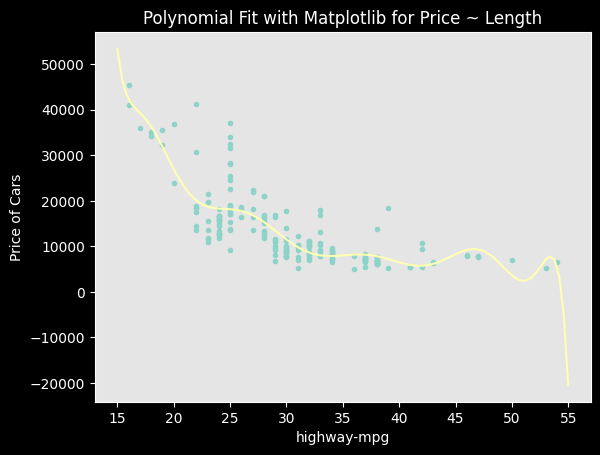

In [17]:
# Create 11 order polynomial model with the variables x and y from above.

# fitting the polynomial using the function polyfit, then use poly1d to generate the Yhat of the polynomial function
f1 = np.polyfit(x,y,11)  # 11 order polynimial with the same above feature (highway-mpg)
p1 = np.poly1d(f1)
print(p1)

# plotting the function
PlotPolly(p1,x,y,'highway-mpg')




### Polynomial Regression with Multi Dimension

* So far we have been doing polynomial function using only single feature, albeit with different level of degree order.
* However, in real life, more than one features is needed to build our prediction model. We have also gone through using Linear Regression for multiple features, but when it comes to Polynomial functions for multi features we will need to use PolynomialFeatures from sklearn.


### IMPORTANT NOTE: The polynomial order number is not related to the number of feature used.
* The Number of Features is about how many different variables we are looking at.
    * A Single Linear Regression uses 1 feature.
    * A Multiple Linear Regression uses 2 or more features. These are multi dimensional polynomial linear regression.
    * Adding more features is like asking more questions to get a better answer.
    * The multi dimensional polynomial functions can be complicated, and numpy polyfit() cannot process them.
    * We use the sickit-learn "preprocessing" libray to process them via PolynomialFeatures object.
    * First we create a PolynomialFeatures object specify the degree order.
    * Then using this object, we invoke fit_transform() passing in a dataframe consisting multiple features.
    * The returned transformation object has an "shape" attribute which tells us how many rows of data, and number of features.

* The Polynomial Order (Complexity/Curve) is about the shape of the relationship for those features.
    * we can have 3rd order model (curves) using only 1 feature.
    * we can have 1st order model (straight lines) using 10 features.



In [18]:
from sklearn.preprocessing import PolynomialFeatures

pr = PolynomialFeatures(degree=2) # create a PolynomialFeatures object of second order degree
print(Z.shape) # our data has 201 samples with 5 features

# first we need to transform Z for PolynomialFeatures
Z_pr = pr.fit_transform(Z)
Z_pr.shape  # after transformation, we will have 21 features 

# Before plotting the PolynomialFeatures graph, we need to understand Pipeline as we will using it to automate
# the process of plotting the graph.

(201, 5)


(201, 21)

### Pipelines
* data pipelines simplify the steps of processing the data from the above transformation object.
* we will need to import the Pipeline and StandardScaler modules for the processing.
* the StandardScaler is used for data normalization which will be perform in the pipeline.
* we create the pipeline by creating a list of tuples including the name of the model or estimator and its corresponding constructor.
* with the pipeline object we can call its fit() method to transform and train the model in the pipeline object.
* we can then do prediction using the model in the pipeline object.

In [19]:
# Pipeline - data pipelines simplify the steps of processing the data.
#   - we will need the Pipeline and StandardScaler modules.

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# we create the pipeline by creating a list of tuples including the name of the model or estimator and its corresponding constructor.
Input = [('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model', LinearRegression())]
pipe = Pipeline(Input) # instantiate the pipeline
print(pipe) # display the content of the pipeline

# convert the data type Z to type float to avoid warnings during transformation
Z = Z.astype(float)

# normalize the data, transform, and train model
pipe.fit(Z,y)

# normalize the data, transform and produce a prediction
ypipe = pipe.predict(Z)

print(ypipe[0:4]) # display the first 4 predicted result


Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])
[13017.47323455 13017.47323455 18403.73142781 10829.46818725]


### Kernel Density Estimation (KDE) Plots for Model Evaluation

Kernel Density Estimation (KDE) plots are a valuable tool for visualizing data distributions by estimating their probability density function (PDF). These plots are particularly useful in regression analysis for comparing actual and predicted values. With the deprecation of Seaborn distplot, KDE plots serve as a modern and effective method for assessing model performance.

* KDE plots are beneficial in model evaluation for the following reasons:
    * They provide a smooth approximation of the data distribution.
    * They help compare the true vs. predicted distributions effectively.
    * Unlike histograms, KDE plots are not sensitive to bin sizes.
    * They can highlight deviations between observed and predicted values.

* Interpretation of the KDE Plot (refer to the plots in the example below)
    * Overlap Between Distributions: 
        * The two curves have a significant overlap, indicating that the model has captured the general distribution of the actual target values reasonably well. However, the predicted values slightly deviate from the actual values in some regions.

    * Peak Differences (Mode Shifts): 
        * The blue (actual) curve peaks slightly higher than the red curve, meaning that the actual values are more concentrated around certain values. The red (predicted) curve has a second peak, suggesting that the model may be slightly misestimating certain ranges of the target variable.

    * Spread of the Distributions: 
        * The actual values (blue) seem to have a wider spread, indicating more variation in real-world values.The predicted values (red) appear to be narrower, which suggests the model might be slightly underestimating variance (a sign of over-smoothing or bias).

    * Tails of the Distributions: 
        * The tails of the predicted values closely follow the actual values, meaning the model does not generate extreme outliers beyond what was observed in the data. If there was a significant mismatch in the tails, it could indicate that the model struggles with extreme cases.



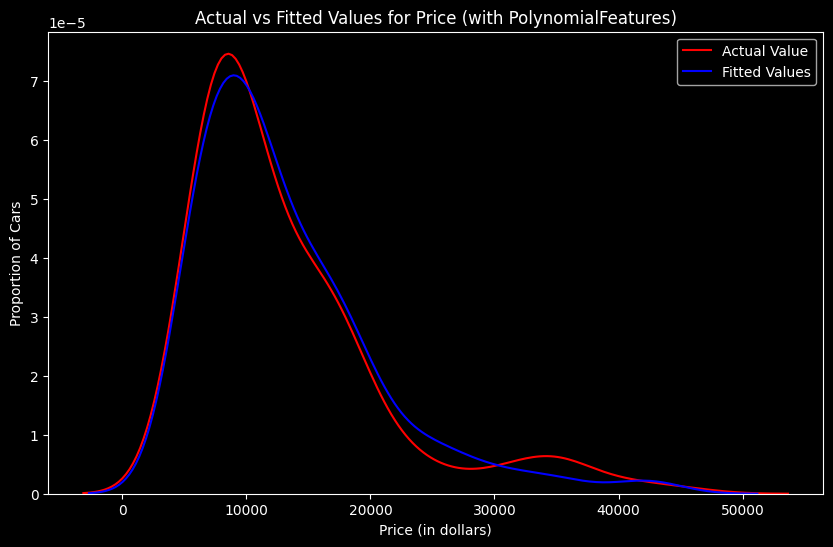

In [20]:
# Visual Evaluation of the Prediction result vs Actual result 

# 1. Generate predictions using the 5-feature pipeline
Y_hat = pipe.predict(df[['horsepower', 'curb-weight', 'engine-size', 'normalized-losses', 'highway-mpg']])

# 2. Plot the distribution of the Actual values vs Predicted values

#   setup graph image size
plt.figure(figsize=(10, 6))

#   Plot the Actual Prices (the "truth")
sns.kdeplot(df['price'], color="r", label="Actual Value")

#   Plot the Predicted Prices (the "model's guess")
sns.kdeplot(Y_hat, color="b", label="Fitted Values")

#   setup the title and axis labels before showing the graph
plt.title('Actual vs Fitted Values for Price (with PolynomialFeatures)')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')
plt.legend()

plt.show()

Pipeline(steps=[('scale', StandardScaler()), ('model', LinearRegression())])


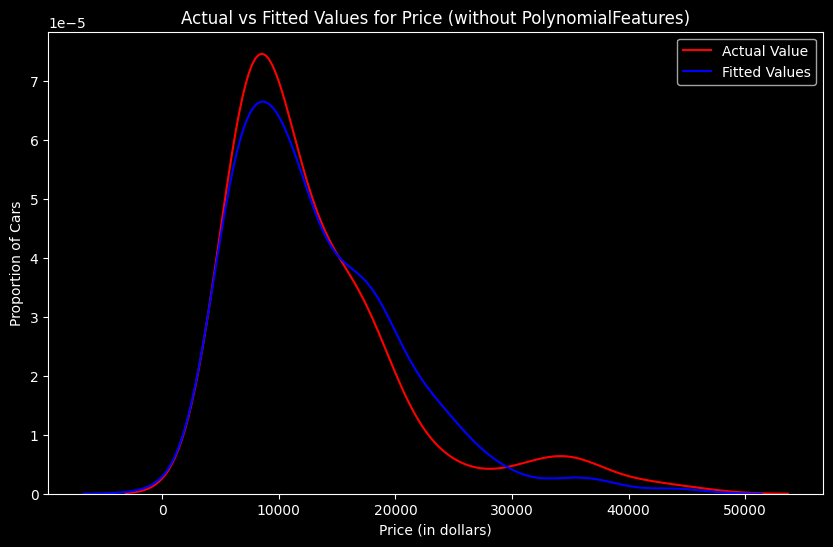

In [21]:
# Question 5: Create a pipeline that standardizes the data, then produce a prediction using a linear regression model using the features Z and target y.

# we create the pipeline by creating a list of tuples including the name of the model or estimator and its corresponding constructor.
Input = [('scale',StandardScaler()), ('model', LinearRegression())] # Note this does not include the PolynomialFeatures
pipe = Pipeline(Input) # instantiate the pipeline
print(pipe) # display the content of the pipeline

# convert the data type Z to type float to avoid warnings during transformation
Z = Z.astype(float)

# normalize the data, transform, and train model
pipe.fit(Z,y)

# normalize the data, transform and produce a prediction
ypipe = pipe.predict(Z)

# Plot the distribution of the Actual values vs Predicted values
plt.figure(figsize=(10, 6))
sns.kdeplot(df['price'], color="r", label="Actual Value")  #   Plot the Actual Prices (the "truth")
sns.kdeplot(ypipe, color="b", label="Fitted Values")  #   Plot the Predicted Prices (the "model's guess")
plt.title('Actual vs Fitted Values for Price (without PolynomialFeatures)')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')
plt.legend()
plt.show()

### Evaluating Models Numerically
Now that we have seen how to evaluate our models through visualization, we want to evaluate our models numerically.

* Measures for In-Sample Evaluation
    * a way to numerically determine how good the model fits on dataset.
    * two important measures to determine the fit of a model are:
        * Mean Squared Error (MSE)
        * R-squared (R^2)
    * we can determine MSE using the mean_squared_error() method from the sklearn.metrics library.
    * MSE measures the average of the squares of errors, i.e. the difference between actual value (y) and the estimates (Yhat).
    * a zero MSE indicates no difference between actual and predicted values.
    * taking the Square-Root of the MSE tells us how far away the difference our predicted value from the actual value.
    * R^2 is also called the Coefficient of Determination.
    * R^2 is a measure to determine how close the data is to the fitted regression line.
    * we can calculate the R^2 using the score() method of the linear regression model object.
    * the R^2 value gives us the confidence level of the predicted result, usually varies from zero to 1.
    * a negative R^2 value indicates OverFitting which we will discuss next.

In [22]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
X = df[['highway-mpg']]  # X must be a dataframe
Y = df['price']  # feeding Y a series, expecting output to be a 1D array

# When evaluating models, in addition to Visualization, we also want to evaluate quantitatively. There two important quantitative measurements:
# 1. R-Squared - also known as coefficient of determination idicate how close the data is to the fitted regression line.
# 2. Mean Squared Error (MSE) - measures the average of the squares of errors, i.e. the difference between actual value (y) and the estimates (Yhat).

print("Example 1: Simple Linear Regression")
lm.fit(X,Y) # highway-mpg fit
print('The R-square is :', lm.score(X,Y))
# We can say that ~49.659% of the variation of the price is explained by this simple linear model "horsepower_fit".

Yhat = lm.predict(X)
print('The output of the first four predicted value is :', Yhat[0:4])
mse = mean_squared_error(df['price'], Yhat)
print('The mean square error of price and predicted value is :', mse)
print()

print('Example 2: Multiple Linear Regression')
lm.fit(Z, df['price'])
print('The R-square is :', lm.score(Z, df['price']))
# We can say that ~80.896 % of the variation of price is explained by this multiple linear regression "multi_fit".

Y_predict_multifit = lm.predict(Z)
print('The mean square error of price and predicted value using multifit is :', mean_squared_error(df['price'], Y_predict_multifit))
print()

print("Example 3: Polynomial Fit")
r_square = r2_score(y, p(X))
print("The R-square value is :", r_square)
# We can say that ~67.419 % of the variation of price is explained by this polynomial fit.
print("The Mean Square Error is:", mean_squared_error(df['price'], p(X)))

# Result Summary:
# Model Type                   R-square       MSE  
# Simple Linear Regression     49.66%        31,635,043 
# Multiple Linear Regression   80.94%        11,976,373
# Polynomial Fit               67.42%        20,474,146 

# Conclusion: Multiple Linear Regression with the highest R-square, and lowest MSE wins !!



Example 1: Simple Linear Regression
The R-square is : 0.4965911884339176
The output of the first four predicted value is : [16236.50464347 16236.50464347 17058.23802179 13771.3045085 ]
The mean square error of price and predicted value is : 31635042.944639888

Example 2: Multiple Linear Regression
The R-square is : 0.8094198310535674
The mean square error of price and predicted value using multifit is : 11976373.258666513

Example 3: Polynomial Fit
The R-square value is : 0.674194666390652
The Mean Square Error is: 20474146.426361218


### Prediction and Decision Making - Testing the Model's "Imagination"
* How can we determine if our model is correct?
    * make sure the model results make sense by visualization, numerical measures, and comparing models.

1. Train the model with the fit() method.
2. Test the model prediction with test data, checking for result that are not extremely high, negative, or extremely low.
3. Compute the model's Coefficient, which indicates the slope of the model's function.
4. Verify visually using Residual and Distribution Plots to see if the prediction make sense.
5. Use the MSE to verify; as the value increases the targets get further away from the predicted points.
6. The R^2 provides the confidence level of our model prediction.

* Comparing Multi Linear Regression vs Simple Linear Regression
    1. A lower MSE doe NOT necessarily imply a better fit.
    2. MSE for a MLR model will be smaller than the MSE for a SLR model since the errors of the data will decrease when more variables are included.
    3. Polynomial Regression will also have a smaller MSE than regular regression.
    4. For R^2, the inverse is true.





lm.coeff : [-821.73337832]


/home/samlau/Python/ML-Projects-and-tutorials/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


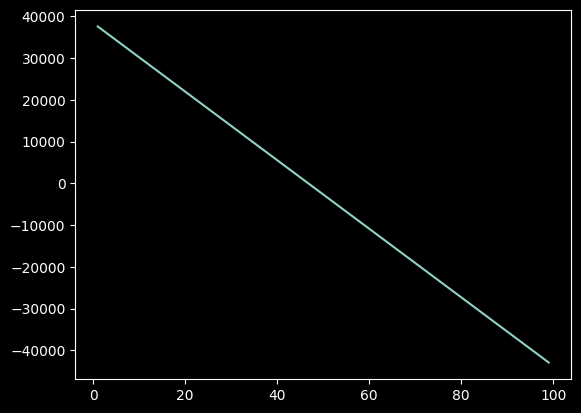

In [23]:
X = df[['highway-mpg']]  # X must be a dataframe
Y = df['price']  # feeding Y a series, expecting output to be a 1D array

# Here we are not just predicting the price of cars we already own; we are creating a 'synthetic' car range to see 
# how the model behaves across the entire spectrum of fuel efficeincy (from 1 to 99 mpg)
new_input = np.arange(1,100,1).reshape(-1,1) # create a synthetic car range

lm.fit(X,Y) # train model with real data
yhat = lm.predict(new_input) # do prediction with synthetic data

print("lm.coeff :", lm.coef_)
plt.plot(new_input, yhat) # plot the graph based on the synthetic data
plt.show()

## Lesson Summary
* Linear regression refers to using one independent variable to make a prediction.

* You can use multiple linear regression to explain the relationship between one continuous target y variable and two or more predictor x variables.

* Simple linear regression, or SLR, is a method used to understand the relationship between two variables, the predictor independent variable x and the target dependent variable y.

* Use the regplot and residplot functions in the Seaborn library to create regression and residual plots, which help you identify the strength, direction, and linearity of the relationship between your independent and dependent variables.

* When using residual plots for model evaluation, residuals should ideally have zero mean, appear evenly distributed around the x-axis, and have consistent variance. If these conditions are not met, consider adjusting your model.

* Use distribution plots for models with multiple features: Learn to construct distribution plots to compare predicted and actual values, particularly when your model includes more than one independent variable. Know that this can offer deeper insights into the accuracy of your model across different ranges of values.

* The order of the polynomials affects the fit of the model to your data. Apply Python's polyfit function to develop polynomial regression models that suit your specific dataset.

* To prepare your data for more accurate modeling, use feature transformation techniques, particularly using the preprocessing library in scikit-learn, transform your data using polynomial features, and use the modules like StandardScaler to normalize the data.

* Pipelines allow you to simplify how you perform transformations and predictions sequentially, and you can use pipelines in scikit-learn to streamline your modeling process.

* You can construct and train a pipeline to automate tasks such as normalization, polynomial transformation, and making predictions.

* To determine the fit of your model, you can perform sample evaluations by using the Mean Square Error (MSE), using Python’s mean_squared_error function from scikit-learn, and using the score method to obtain the R-squared value.

* A model with a high R-squared value close to 1 and a low MSE is generally a good fit, whereas a model with a low R-squared and a high MSE may not be useful.

* Be alert to situations where your R-squared value might be negative, which can indicate overfitting. 

* When evaluating models, use visualization and numerical measures and compare different models.

* The mean square error is perhaps the most intuitive numerical measure for determining whether a model is good.

* A distribution plot is a suitable method for multiple linear regression.

* An acceptable r-squared value depends on what you are studying and your use case.

* To evaluate your model’s fit, apply visualization, methods like regression and residual plots, and numerical measures such as the model's coefficients for sensibility: 

    * Use Mean Square Error (MSE) to measure the average of the squares of the errors between actual and predicted values and examine R-squared to understand the proportion of the variance in the dependent variable that is predictable from the independent variables.

    * When analyzing residual plots, residuals should be randomly distributed around zero for a good model. In contrast, a residual plot curve or inaccuracies in certain ranges suggest non-linear behavior or the need for more data.

    